# Physics-Informed Neural Networks for Holographic QCD

## Overview

This notebook applies physics-informed neural networks (PINNs) to the **Dynamic AdS/YM model** of holographic QCD, in two stages:

- **Task 1 — Forward problem**: train a PINN to learn the vacuum embedding $L(\rho)$ from the equation of motion (EOM). Validate against an independent scipy shooting solution.
- **Task 2 — Inverse problem**: starting from the Task 1 baseline, ask whether $L(\rho)$ can be modified to reproduce the experimental $\rho$-meson spectrum and the pion decay constant $f_\pi$. This is a pure-inverse problem with experimental data as the only target.

### References

- Evans, Jones, and Scott (arXiv:1508.06540) — the Dynamic AdS/YM model
- Erdmenger, Evans, Porod, and Rigatos (arXiv:2010.10279) — meson spectrum applications
- Witten (arXiv:hep-th/0112258) — multi-trace deformations in AdS/CFT

### Gauge theory

Quantum chromodynamics (QCD) with $N_c = 3$ colours and $N_f = 2$ light flavours.

### Headline result

The Dynamic AdS/YM model in the standard chiral limit ($L(\rho_{\text{UV}}) = 0$) **cannot fit the experimental $\rho$-meson tower simultaneously with $f_\pi$**. Multiple independent approaches (regularised neural network, parametric Chebyshev expansion, anchor-constrained variants) all converge on the same residual pattern. The structural mismatch — the model produces near-linear-in-$n$ mass spacing while experiment shows Regge-like behaviour — is a known limitation of holographic QCD that motivates higher-dimensional operator (HDO) extensions.

---


## Part 1 — Imports, physics constants, and setup

In [1]:
# All imports for the entire notebook
import copy

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.linalg import eig as scipy_eig
from scipy.interpolate import interp1d


# Device selection — MPS for Apple Silicon, CUDA for NVIDIA GPU, CPU as fallback
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: mps


### Physics constants

QCD parameters from arXiv:1508.06540.

| Quantity | Expression | Value |
|---|---|---|
| $b_0$ | $(11 N_c - 2 N_f)/(6\pi)$ | $29/(6\pi)$ |
| $b_1$ | $[34 N_c^2 - 10 N_c N_f - 3(N_c^2-1)N_f/N_c]/(24\pi^2)$ | $230/(24\pi^2)$ |
| $\gamma_{\text{coeff}}$ | $3(N_c^2-1)/(4 N_c \pi)$ | $2/\pi$ |
| $g_5^2$ | $24\pi^2/(N_c N_f)$ | $4\pi^2$ |

The two-loop beta function is $\alpha'(\mu) = -b_0 \alpha^2 - b_1 \alpha^3$ with $\mu = \ln(r)$.
The mass-squared parameter is $\Delta m^2(\mu) = -2\gamma(\mu) = -(4/\pi)\,\alpha(\mu)$.

In [2]:
# QCD with Nc = 3 colours and Nf = 2 flavours

Nc = 3 
Nf = 2 

# Coefficients of the two-loop beta function
b0 = (11 * Nc - 2 * Nf) / (6 * np.pi) 
b1 = (34 * Nc**2 - 10 * Nc * Nf - 3 * ((Nc**2 - 1) / Nc) * Nf ) / (24 * np.pi**2) 

# Coefficient of anomalous dimension 
gamma_coeff = 3 * (Nc**2 - 1) / (4 * Nc * np.pi) 

# The five-dimensional gauge coupling 
g5_sq = 24 * np.pi**2 / (Nc * Nf) 

# Initial condition for the coupling at mu = 0 = ln(r) 
alpha_0 = 0.65 

# Max value/UV cut-off 
rho_max = 10 

# Print for verification against my old Mathematica notebooks
print("=" * 50)
print("Physics constants — verify against Mathematica")
print("=" * 50)
print(f"b0          = {b0:.8f}   (= 29/(6*pi))")
print(f"b1          = {b1:.8f}   (= 230/(24*pi^2))")
print(f"gamma_coeff = {gamma_coeff:.8f}   (= 2/pi)")
print(f"g5_sq       = {g5_sq:.8f}   (= 4*pi^2)")
print(f"alpha(0)    = {alpha_0}")
print(f"rho_max     = {rho_max}")

Physics constants — verify against Mathematica
b0          = 1.53849778   (= 29/(6*pi))
b1          = 0.97099468   (= 230/(24*pi^2))
gamma_coeff = 0.63661977   (= 2/pi)
g5_sq       = 39.47841760   (= 4*pi^2)
alpha(0)    = 0.65
rho_max     = 10


### Solve the running coupling $\alpha(\mu)$

Integrate the two-loop beta function outward from $\mu = 0$ in both directions. The IR integration stops near the Landau pole (we use $\alpha = 50$ as the cutoff, mirroring the Mathematica `StiffnessSwitching` behaviour).

The IR integration stopped at mu = -0.493236
The reference value from Mathematica is: mu = -0.493436

alpha(mu=0)        = 0.650000  (expected: 0.65)
Delta m^2(mu=0)    = -0.827606


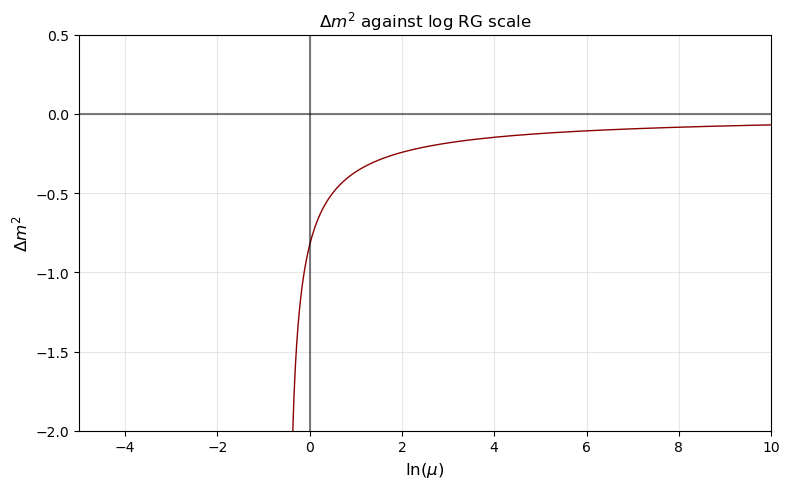

In [3]:
# Solve alpha(mu) — outward integration from mu = 0 in both directions

def beta_function(mu, alpha): 
    """The two-loop beta function: d(alpha)/d(mu) = -b0 * alpha^2 - b1 * alpha^3"""
    derivative = -b0 * alpha[0]**2 - b1 * alpha[0]**3 
    return [derivative] 

def alpha_blowup_event(mu, alpha): 
    """Stop the IR integration when alpha exceeds 50 - the Landau pole region"""
    landau_pole = alpha[0] - 50.0 
    return landau_pole
alpha_blowup_event.terminal = True 

# negative values for mu; IR  direction --- coupling grows towards Landau pole 
sol_alpha_IR = solve_ivp(
    beta_function, [0, -5.0], [alpha_0], 
    method = 'Radau', dense_output = True, 
    rtol = 1e-12, atol = 1e-12, events = alpha_blowup_event 
)

# going to the UV; asymptotic freedom 
sol_alpha_UV = solve_ivp(
    beta_function, [0, 50], [alpha_0],
    method='Radau', dense_output=True,
    rtol=1e-12, atol=1e-12
)

mu_IR_limit = sol_alpha_IR.t[-1] 
print(f"The IR integration stopped at mu = {mu_IR_limit:.6f}")
print(f"The reference value from Mathematica is: mu = -0.493436")

def alpha_of_mu(mu): 
    """Evaluate alpha at any mu, freezing at the IR limit.""" 
    mu = float(mu) 
    if mu <= mu_IR_limit: 
        sltn_for_return = float(sol_alpha_IR.sol(mu_IR_limit)[0])  
        return sltn_for_return
    elif mu < 0: 
        sltn_for_return = float(sol_alpha_IR.sol(mu)[0])  
        return sltn_for_return 
    return float(sol_alpha_UV.sol(mu)[0])

def gamma_of_mu(mu):
    """Anomalous dimension: gamma = gamma_coeff * alpha"""
    gamma_return = gamma_coeff * alpha_of_mu(mu) 
    return gamma_return 

def delta_m2_of_mu(mu): 
    """Running mass-squared: Delta m^2 = - 2 * gamma""" 
    delta_m2_return = -2 * gamma_of_mu(mu) 
    return delta_m2_return 

# Verification
print(f"\nalpha(mu=0)        = {alpha_of_mu(0):.6f}  (expected: 0.65)")
print(f"Delta m^2(mu=0)    = {delta_m2_of_mu(0):.6f}") 

# Plot Delta m^2  
mu_plot = np.linspace(-5, 10, 500) 
dm2_plot = np.array([delta_m2_of_mu(m) for m in mu_plot])
plt.figure(figsize=(8, 5))
plt.plot(mu_plot, dm2_plot, color = 'darkred', linewidth = 1) 
plt.axvline(x = 0, color='black', linestyle = '-', alpha= 0.5)
plt.axhline(y = 0, color='black', linestyle = '-', alpha= 0.5)
plt.xlabel(r'$\ln(\mu)$', fontsize=12)
plt.ylabel(r'$\Delta m^2$', fontsize=12)
plt.xlim(-5, 10)
plt.ylim(-2, 0.5) 
plt.grid(True, alpha=0.3)
plt.title(r'$\Delta m^2$ against log RG scale')
plt.tight_layout()
plt.show() 

### Ground truth $L(\rho)$ via scipy shooting

The vacuum equation of motion:

$$L'' = -\frac{3}{\rho}\,L' + \frac{\Delta m^2\!\left(\ln\sqrt{\rho^2 + L^2}\right)}{\rho^2}\,L$$

with boundary conditions $L(\rho_{\text{IR}}) = \rho_{\text{IR}}$, $L'(\rho_{\text{IR}}) = 0$ (IR mass condition) and $L(\rho_{\text{max}}) = 0$ (UV chiral limit). The shooting parameter $\rho_{\text{IR}}$ is tuned by `brentq` until the UV condition is met.

Mathematica reference: $\rho_{\text{IR}} = 0.431704$.

rho_IR             = 0.4315633773
L(rho_max)         = 1.41e-13
Mathematica value  = 0.431704

L(rho_IR)          = 0.4315633773
Monotonically decreasing (to 1e-10 tolerance): True


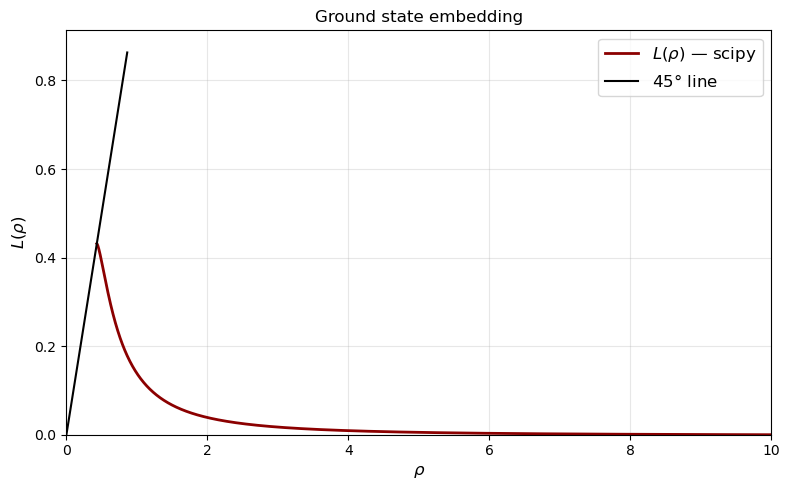

In [4]:
# Shooting from the IR such that the UV condition is satisfied 

def L_ode_system(rho, y):
    """
    First-order system for the L(rho) ODE.
    y[0] = L(rho), y[1] = L'(rho)
    """
    L_val, L_prime = y
    mu_val = 0.5 * np.log(rho**2 + L_val**2)
    dm2 = delta_m2_of_mu(mu_val)
    L_double_prime = -(3.0 / rho) * L_prime + (dm2 / rho**2) * L_val
    system_return = [L_prime, L_double_prime]
    return system_return


def solve_L_from_IR(rho_ir):
    """Integrate L from rho_ir to rho_max with IR boundary conditions."""
    sltn_ivp_return = solve_ivp(
        L_ode_system, [rho_ir, rho_max], [rho_ir, 0.0],
        method='Radau', dense_output=True,
        rtol=1e-12, atol=1e-12, max_step=0.005
    )
    return sltn_ivp_return 

def L_at_UV(rho_ir):
    """Return L(rho_max) for a given shooting parameter."""
    sol = solve_L_from_IR(rho_ir)
    if sol.success:
        return float(sol.sol(rho_max)[0])
    return float(sol.y[0, -1])


# Tune rho_IR — bracketed search
rho_IR = brentq(L_at_UV, 0.4300, 0.4350, xtol=1e-12)
print(f"rho_IR             = {rho_IR:.10f}")
print(f"L(rho_max)         = {L_at_UV(rho_IR):.2e}")
print(f"Mathematica value  = 0.431704")
print()

# Ground truth on a fine grid for later comparison
sol_ground_truth = solve_L_from_IR(rho_IR)
rho_grid_gt = np.linspace(rho_IR, rho_max, 2000)
L_ground_truth = sol_ground_truth.sol(rho_grid_gt)[0]

print(f"L(rho_IR)          = {L_ground_truth[0]:.10f}")
strict_decrease = np.all(np.diff(L_ground_truth) < 1e-10)
print(f"Monotonically decreasing (to 1e-10 tolerance): {strict_decrease}")

# Plot the vacuum of the theory 
plt.figure(figsize=(8, 5))
plt.plot(rho_grid_gt, L_ground_truth, color='darkred', linewidth=2,
         label=r'$L(\rho)$ — scipy')
plt.plot([0, 2*rho_IR], [0, 2*rho_IR], 'k-', linewidth=1.5,
         label=r'$45°$ line')
plt.xlabel(r'$\rho$', fontsize=12)
plt.ylabel(r'$L(\rho)$', fontsize=12)
plt.xlim(0, rho_max)
plt.ylim(0, 2*rho_IR + 0.05)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title(r'Ground state embedding')
plt.tight_layout()
plt.show() 

## Part 2 — Task 1: PINN for the vacuum embedding

### Network architecture with hard boundary conditions

We parametrise $L(\rho)$ using a multi-layer perceptron $N(\rho)$, then construct the network output to satisfy both Dirichlet boundary conditions exactly:

$$L(\rho) = \rho_{\text{IR}} \cdot \frac{\rho_{\text{max}} - \rho}{\rho_{\text{max}} - \rho_{\text{IR}}} + (\rho - \rho_{\text{IR}})(\rho_{\text{max}} - \rho) \cdot N(\rho)$$

The linear term satisfies $L(\rho_{\text{IR}}) = \rho_{\text{IR}}$ and $L(\rho_{\text{max}}) = 0$, and the correction vanishes at both boundaries. The Neumann condition $L'(\rho_{\text{IR}}) = 0$ is enforced as a soft penalty.

### Activation function choice

We use `tanh` rather than `ReLU`. PINNs compute second derivatives of the network output via automatic differentiation; `ReLU` has $\sigma''(x) = 0$ almost everywhere, so a `ReLU` PINN cannot represent the curvature $L''(\rho)$ in the equation of motion. Smooth activations are essential.

In [5]:
# PyTorch-compatible alpha(mu) via linear interpolation on a dense lookup table 

mu_table = np.linspace(-1.0, 5.0, 10000)
alpha_table = np.array([alpha_of_mu(m) for m in mu_table])

mu_table_torch = torch.tensor(mu_table, dtype=torch.float64)
alpha_table_torch = torch.tensor(alpha_table, dtype=torch.float64)

def alpha_torch(mu_tensor):
    """
    Linear interpolation of alpha(mu) for PyTorch autograd compatibility.
    Differentiable through mu_tensor.
    """
    # Flatten and clamp mu to the tabulated range 
    mu_flat = mu_tensor.reshape(-1)
    mu_clamped = torch.clamp(mu_flat, mu_table_torch[0], mu_table_torch[-1])
    
    # Fractional index into the table
    N_table = len(mu_table_torch)
    table_span = mu_table_torch[-1] - mu_table_torch[0]
    idx_float = (mu_clamped - mu_table_torch[0]) / table_span * (N_table - 1) 
    idx_low = torch.clamp(idx_float.long(), 0, N_table - 2)
    frac = idx_float - idx_low.double()
    
    # Linear interpolation between the two bracketing table values
    alpha_low = alpha_table_torch[idx_low]
    alpha_high = alpha_table_torch[idx_low + 1]
    alpha_interp = alpha_low + frac * (alpha_high - alpha_low)
    
    alpha_return = alpha_interp.reshape(mu_tensor.shape) 
    return alpha_return

def delta_m2_torch(mu_tensor):
    """Delta m^2 = -2 * gamma_coeff * alpha, differentiable through autograd."""
    delta_m2_return = -2 * gamma_coeff * alpha_torch(mu_tensor)
    return delta_m2_return

In [6]:
# Neural network for L(rho) with hard-enforced Dirichlet boundary conditions

class LNetwork(nn.Module):
    """
    Multi-layer perceptron approximation of L(rho).
    
    Architecture: 5 hidden layers x 64 neurons, tanh activations, float64.
    The output satisfies L(rho_IR) = rho_IR and L(rho_max) = 0 exactly,
    enforced by the ansatz structure.
    """
    def __init__(self, rho_ir, rho_uv, hidden_dim=64, n_layers=5):
        super().__init__()
        self.register_buffer('rho_ir', torch.tensor(rho_ir, dtype=torch.float64))
        self.register_buffer('rho_uv', torch.tensor(rho_uv, dtype=torch.float64))
        self.register_buffer('L_ir', torch.tensor(rho_ir, dtype=torch.float64))
        
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)
        self.double()
    
    def forward(self, rho):
        N_rho = self.net(rho)
        linear_part = self.L_ir * (self.rho_uv - rho) / (self.rho_uv - self.rho_ir)
        correction = (rho - self.rho_ir) * (self.rho_uv - rho) * N_rho
        L_return = linear_part + correction 
        return L_return

# Instantiate and verify boundary conditions
model = LNetwork(rho_IR, rho_max, hidden_dim=64, n_layers=5)
n_params = sum(p.numel() for p in model.parameters())

print(f"Network: 5 layers x 64 hidden, tanh activations, float64")
print(f"Total parameters: {n_params}")

rho_test_IR = torch.tensor([[rho_IR]], dtype=torch.float64)
rho_test_UV = torch.tensor([[rho_max]], dtype=torch.float64)
print(f"\nL(rho_IR)  = {model(rho_test_IR).item():.10f}  (exact: {rho_IR:.10f})")
print(f"L(rho_max) = {model(rho_test_UV).item():.10f}  (exact: 0.0)")

Network: 5 layers x 64 hidden, tanh activations, float64
Total parameters: 16833

L(rho_IR)  = 0.4315633773  (exact: 0.4315633773)
L(rho_max) = 0.0000000000  (exact: 0.0)


### PINN loss function

The physics residual is the **normalised** equation of motion:

$$\text{Residual}(\rho) = \rho \, L''(\rho) + 3\, L'(\rho) - \frac{\Delta m^2}{\rho}\, L(\rho)$$

Dividing the original equation by $\rho^2$ keeps the residual $\mathcal{O}(1)$ across the domain. Without this normalisation, the $\rho^3$ factor in front of $L''$ would make the residual dominated by the UV region, where $L \approx 0$ is trivial to fit.

In [7]:
# PINN loss: normalised PDE residual + soft Neumann boundary condition

def compute_derivatives(model, rho):
    """Compute L, L', and L'' at given points using torch.autograd."""
    rho = rho.detach().requires_grad_(True)
    L_val = model(rho) 
    
    # First derivative via autograd 
    L_prime = torch.autograd.grad(
        L_val, rho, torch.ones_like(L_val), create_graph=True
    )[0]
    
    # Second derivative — differentiate the first derivative once more 
    L_double_prime = torch.autograd.grad(
        L_prime, rho, torch.ones_like(L_prime), create_graph=True
    )[0]
    
    return L_val, L_prime, L_double_prime


def pinn_loss(model, rho_collocation, rho_ir_point, lambda_bc=50.0):
    """
    Total loss = normalised PDE residual + soft Neumann boundary penalty.
    
    The Dirichlet BCs are hard-enforced by the architecture.
    Only the derivative condition L'(rho_IR) = 0 needs a soft penalty.
    """
    # PDE residual (normalised by rho^2 to keep O(1) across the domain)
    L_val, L_prime, L_double_prime = compute_derivatives(model, rho_collocation)
    r_squared = rho_collocation**2 + L_val**2
    mu_val = 0.5 * torch.log(r_squared)
    dm2 = delta_m2_torch(mu_val)
    
    residual = rho_collocation * L_double_prime + 3.0 * L_prime - dm2 * L_val / rho_collocation
    loss_pde = torch.mean(residual**2)
    
    # Neumann BC at IR
    _, L_prime_ir, _ = compute_derivatives(model, rho_ir_point)
    loss_bc = torch.mean(L_prime_ir**2)

    # Total loss with soft BC weighting 
    total = loss_pde + lambda_bc * loss_bc
    return total, loss_pde, loss_bc

### Training: Adam + L-BFGS

Two-phase optimisation:
1. **Adam** (10,000 epochs) — fast initial convergence with adaptive learning rate
2. **L-BFGS** (500 epochs) — second-order refinement to high precision

Collocation points: 800 total, with 60% log-spaced near the IR where $L(\rho)$ varies fastest, and 40% linearly spaced in the bulk/UV.

In [8]:
# Collocation points with denser sampling near the IR

N_collocation = 800

rho_near_ir = torch.logspace(
    np.log10(rho_IR + 1e-4), np.log10(rho_IR + 2.0),
    int(0.6 * N_collocation), dtype=torch.float64
)
rho_bulk_uv = torch.linspace(
    rho_IR + 2.0, rho_max,
    int(0.4 * N_collocation), dtype=torch.float64
)

rho_collocation = torch.cat([rho_near_ir, rho_bulk_uv]).unsqueeze(1)
rho_ir_point = torch.tensor([[rho_IR]], dtype=torch.float64)

print(f"Collocation points: {rho_collocation.shape[0]}")
print(f"Range: [{rho_collocation.min().item():.4f}, {rho_collocation.max().item():.4f}]")

Collocation points: 800
Range: [0.4317, 10.0000]


In [9]:
# Phase 1: Adam optimiser
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

# Halve LR when the loss plateaus for 1000 epochs — helps L-BFGS start from a better point 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adam, patience=1000, factor=0.5, min_lr=1e-6
)

n_epochs_adam = 10000
lambda_bc = 50.0

history = {'total': [], 'pde': [], 'bc': []}

print("Phase 1: Adam")
print(f"{'Epoch':>7s}  {'Total':>12s}  {'PDE':>12s}  {'BC':>12s}  {'LR':>10s}")
print("-" * 60)

for epoch in range(n_epochs_adam):
    optimizer_adam.zero_grad()
    total, pde, bc = pinn_loss(model, rho_collocation, rho_ir_point, lambda_bc)
    total.backward()
    optimizer_adam.step()
    scheduler.step(total.item())
    
    history['total'].append(total.item())
    history['pde'].append(pde.item())
    history['bc'].append(bc.item())
    
    if (epoch + 1) % 2000 == 0 or epoch == 0:
        lr = optimizer_adam.param_groups[0]['lr']
        print(f"{epoch+1:7d}  {total.item():12.4e}  {pde.item():12.4e}  "
              f"{bc.item():12.4e}  {lr:10.2e}")

print(f"\nAdam final loss: {history['total'][-1]:.4e}")

Phase 1: Adam
  Epoch         Total           PDE            BC          LR
------------------------------------------------------------
      1    7.5880e+00    7.4494e+00    2.7718e-03    1.00e-03
   2000    9.9556e-01    9.7730e-01    3.6518e-04    1.00e-03
   4000    2.6259e-01    1.9390e-01    1.3738e-03    1.00e-03
   6000    6.2405e-02    5.7001e-02    1.0807e-04    1.00e-03
   8000    1.2361e-01    9.0652e-02    6.5918e-04    1.00e-03
  10000    1.5857e-02    1.2900e-02    5.9132e-05    1.00e-03

Adam final loss: 1.5857e-02


In [10]:
# Phase 2: L-BFGS optimiser

# L-BFGS with strong Wolfe line search — the standard robust choice for PINN refinement
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0, max_iter=20, max_eval=25, history_size=50,
    tolerance_grad=1e-12, tolerance_change=1e-14,
    line_search_fn='strong_wolfe'
)

n_epochs_lbfgs = 500
n_adam = len(history['total'])

print("Phase 2: L-BFGS")
print(f"{'Epoch':>7s}  {'Total':>12s}  {'PDE':>12s}  {'BC':>12s}")
print("-" * 50)

for epoch in range(n_epochs_lbfgs):
    def closure():
        optimizer_lbfgs.zero_grad()
        total, _, _ = pinn_loss(model, rho_collocation, rho_ir_point, lambda_bc)
        total.backward()
        return total
    
    optimizer_lbfgs.step(closure)
    
    total, pde, bc = pinn_loss(model, rho_collocation, rho_ir_point, lambda_bc)
    history['total'].append(total.item())
    history['pde'].append(pde.item())
    history['bc'].append(bc.item())
    
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"{epoch+1:7d}  {total.item():12.4e}  {pde.item():12.4e}  "
              f"{bc.item():12.4e}")

print(f"\nL-BFGS final loss: {history['total'][-1]:.4e}")

Phase 2: L-BFGS
  Epoch         Total           PDE            BC
--------------------------------------------------
      1    6.5913e-03    6.5892e-03    4.1036e-08
    100    7.0668e-06    7.0667e-06    3.3879e-12
    200    7.0622e-06    7.0621e-06    3.3493e-12
    300    7.0586e-06    7.0584e-06    3.1203e-12
    400    7.0557e-06    7.0555e-06    3.3967e-12
    500    7.0532e-06    7.0531e-06    3.3804e-12

L-BFGS final loss: 7.0532e-06


### Validate Task 1: PINN vs scipy ground truth

PINN vs ground truth — Task 1 validation
Max absolute error:  3.4394e-03
Mean absolute error: 1.8101e-03
Max relative error (|L| > 0.05):  6.7758e-02
Mean relative error (|L| > 0.05): 3.0132e-02

Boundary verification:
  L_PINN(rho_IR)  = 0.4315633773  (exact: 0.4315633773)
  L_PINN(rho_max) = 0.0000000000  (exact: 0.0)
  L'_PINN(rho_IR) = -1.838594e-06  (target: 0.0)


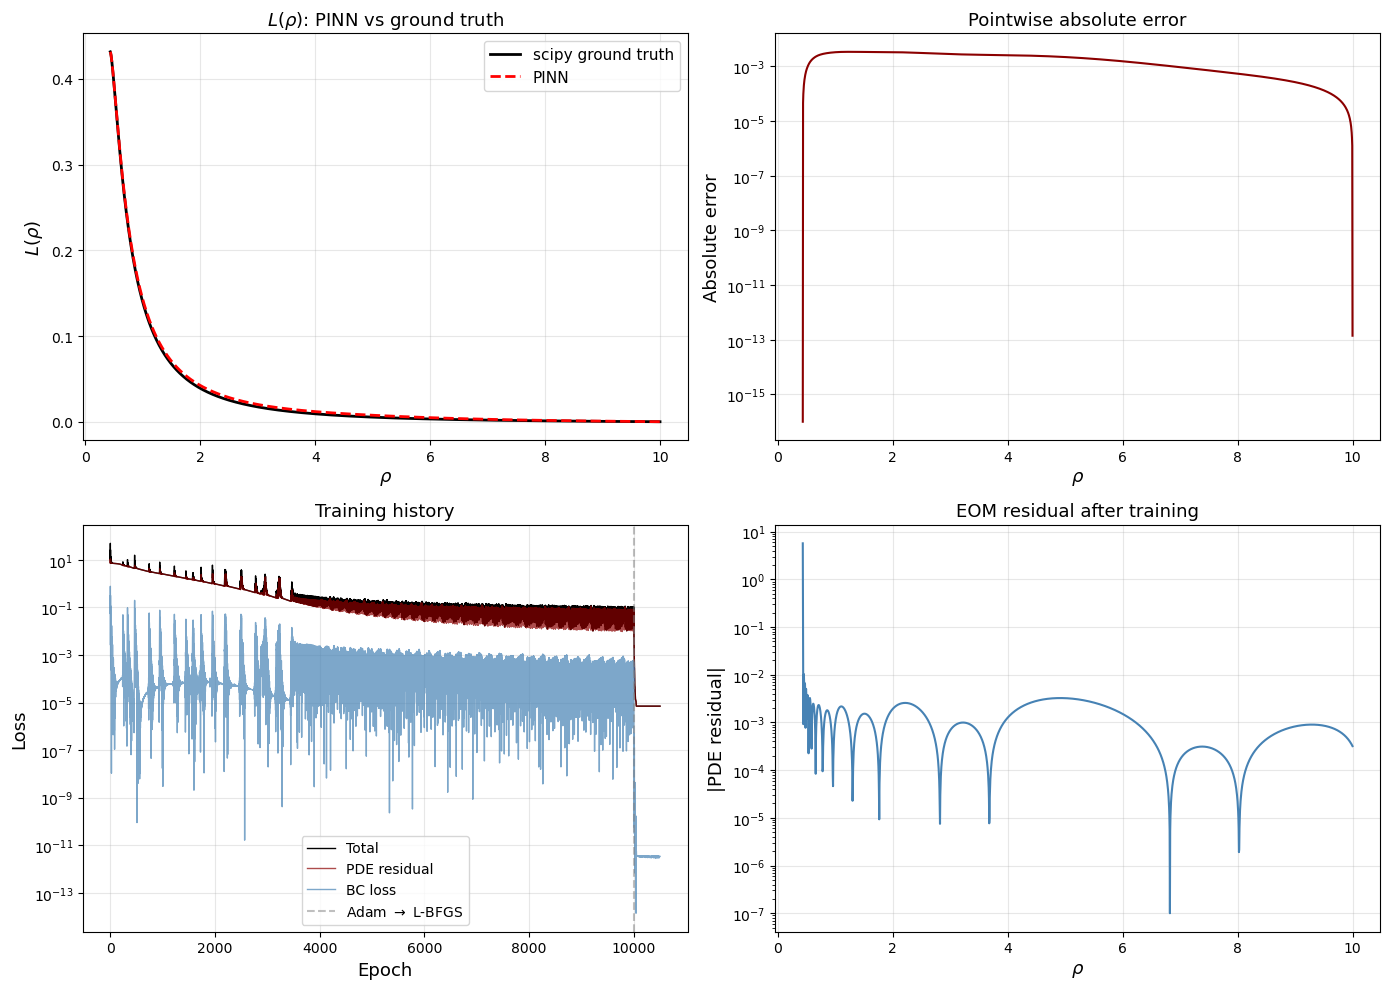

In [11]:
# Compare the PINN output to the scipy shooting solution

rho_eval = torch.tensor(rho_grid_gt, dtype=torch.float64).unsqueeze(1)
with torch.no_grad():
    L_pinn = model(rho_eval).squeeze().numpy()

absolute_error = np.abs(L_pinn - L_ground_truth)
nonzero_mask = np.abs(L_ground_truth) > 0.05
relative_error = np.zeros_like(absolute_error)
relative_error[nonzero_mask] = absolute_error[nonzero_mask] / np.abs(L_ground_truth[nonzero_mask])

print("=" * 50)
print("PINN vs ground truth — Task 1 validation")
print("=" * 50)
print(f"Max absolute error:  {np.max(absolute_error):.4e}")
print(f"Mean absolute error: {np.mean(absolute_error):.4e}")
print(f"Max relative error (|L| > 0.05):  {np.max(relative_error[nonzero_mask]):.4e}")
print(f"Mean relative error (|L| > 0.05): {np.mean(relative_error[nonzero_mask]):.4e}")
print()

print("Boundary verification:")
print(f"  L_PINN(rho_IR)  = {L_pinn[0]:.10f}  (exact: {rho_IR:.10f})")
print(f"  L_PINN(rho_max) = {L_pinn[-1]:.10f}  (exact: 0.0)")

# Check the Neumann BC by autograd
rho_ir_check = torch.tensor([[rho_IR]], dtype=torch.float64).requires_grad_(True)
L_ir_val = model(rho_ir_check)
L_prime_ir = torch.autograd.grad(L_ir_val, rho_ir_check,
                                   grad_outputs=torch.ones_like(L_ir_val))[0]
print(f"  L'_PINN(rho_IR) = {L_prime_ir.item():.6e}  (target: 0.0)")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(rho_grid_gt, L_ground_truth, 'k-', linewidth=2, label='scipy ground truth')
axes[0, 0].plot(rho_grid_gt, L_pinn, 'r--', linewidth=2, label='PINN')
axes[0, 0].set_xlabel(r'$\rho$', fontsize=13)
axes[0, 0].set_ylabel(r'$L(\rho)$', fontsize=13)
axes[0, 0].set_title(r'$L(\rho)$: PINN vs ground truth', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].semilogy(rho_grid_gt, absolute_error + 1e-16, color='darkred', linewidth=1.5)
axes[0, 1].set_xlabel(r'$\rho$', fontsize=13)
axes[0, 1].set_ylabel('Absolute error', fontsize=13)
axes[0, 1].set_title('Pointwise absolute error', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].semilogy(history['total'], 'k-', linewidth=1, label='Total')
axes[1, 0].semilogy(history['pde'], color='darkred', linewidth=1, alpha=0.7, label='PDE residual')
axes[1, 0].semilogy(history['bc'], color='steelblue', linewidth=1, alpha=0.7, label='BC loss')
axes[1, 0].axvline(x=n_adam, color='gray', linestyle='--', alpha=0.5, label=r'Adam $\to$ L-BFGS')
axes[1, 0].set_xlabel('Epoch', fontsize=13)
axes[1, 0].set_ylabel('Loss', fontsize=13)
axes[1, 0].set_title('Training history', fontsize=13)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

rho_eval_torch = torch.tensor(rho_grid_gt, dtype=torch.float64).unsqueeze(1)
L_final, L_prime_final, L_dp_final = compute_derivatives(model, rho_eval_torch)
r_squared_final = rho_eval_torch**2 + L_final**2
mu_final = 0.5 * torch.log(r_squared_final)
dm2_final = delta_m2_torch(mu_final)
residual_final = (rho_eval_torch * L_dp_final + 3.0 * L_prime_final - 
                  dm2_final * L_final / rho_eval_torch)
residual_final_np = residual_final.detach().squeeze().numpy()

axes[1, 1].semilogy(rho_grid_gt, np.abs(residual_final_np) + 1e-16, 
                    color='steelblue', linewidth=1.5)
axes[1, 1].set_xlabel(r'$\rho$', fontsize=13)
axes[1, 1].set_ylabel('|PDE residual|', fontsize=13)
axes[1, 1].set_title('EOM residual after training', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 3 — Task 2: Inverse problem with PDG data

We now ask whether $L(\rho)$ can be modified to reproduce the experimental $\rho$-meson spectrum. This requires three pieces of new infrastructure:

1. A discretisation method to solve linear ODEs and eigenvalue problems on the domain $[\rho_{\text{IR}}, \rho_{\text{max}}]$
2. A vector meson eigensolve that takes $L(\rho)$ and returns the meson masses
3. A pion decay constant computation $f_\pi$ for anchoring the energy scale

All three are implemented as **differentiable** PyTorch functions so that gradients flow back to the trainable parameters.

### Discretisation: Chebyshev spectral collocation

We use Chebyshev-Gauss-Lobatto collocation on $[\rho_{\text{IR}}, \rho_{\text{max}}]$ with $N+1 = 51$ points. For smooth functions this gives exponential (spectral) convergence: machine precision is reached at $N \approx 30$, vastly better than the algebraic $O(h^2)$ convergence of standard second-order finite differences.

The Chebyshev differentiation matrix is constructed using the Trefethen formula (*Spectral Methods in MATLAB*).

In [12]:
# Chebyshev differentiation matrix on the reference interval [-1, 1]

def chebyshev_diff_matrix(N):
    """
    Build the Chebyshev-Gauss-Lobatto nodes and differentiation matrix on [-1, 1].
    Uses the standard Trefethen formula. Returns:
        x : (N+1,) — Chebyshev nodes, ordered from +1 (k=0) to -1 (k=N)
        D : (N+1, N+1) — differentiation matrix
    """
    if N == 0:
        single_node = np.array([1.0])
        zero_matrix = np.array([[0.0]])
        return single_node, zero_matrix
    
    # Chebyshev nodes: x_k = cos(k*pi/N)
    k_indices = np.arange(N + 1)
    x = np.cos(np.pi * k_indices / N)
    
    # Coefficients c_k * (-1)^k for the formula
    c = np.ones(N + 1)
    c[0] = 2.0
    c[N] = 2.0
    c = c * (-1.0) ** k_indices
    
    # Off-diagonal entries via outer products
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    np.fill_diagonal(dX, 1.0)   # temporary to avoid division by zero

    # Off-diagonal formula: D_ij = (c_i/c_j) / (x_i - x_j)
    C_outer = np.outer(c, 1.0 / c)
    # Element-wise division to scale the coefficient ratios by coordinate differences 
    D = C_outer / dX
    
    # Diagonal via the negative-sum trick (each row of D sums to zero)
    D = D - np.diag(np.sum(D, axis=1))

    nodes_return = x 
    diff_matrix_return = D 
    
    return nodes_return, diff_matrix_return


def build_chebyshev_grid(rho_IR_in, rho_max_in, N):
    """
    Build the Chebyshev grid on [rho_IR_in, rho_max_in] and the corresponding
    first and second derivative matrices.
    
    Affine map: rho = (b-a)/2 * x + (a+b)/2, with Jacobian 2/(b-a) applied to D.
    Second derivative: D2 = D1 @ D1.
    """
    x_std, D_std = chebyshev_diff_matrix(N)
    
    domain_lower = rho_IR_in
    domain_upper = rho_max_in
    # Affine map from [-1, 1] to [domain_lower, domain_upper] 
    rho_unordered = 0.5 * (domain_upper - domain_lower) * x_std + 0.5 * (domain_upper + domain_lower)
    
    jacobian = 2.0 / (domain_upper - domain_lower)
    D1_unordered = jacobian * D_std
    
    # Reorder smallest to largest rho (default Chebyshev order is +1 down to -1)
    order = np.argsort(rho_unordered)
    rho_grid = rho_unordered[order]
    D1 = D1_unordered[order, :][:, order]
    D2 = D1 @ D1

    # Return the grid and both derivative matrices
    return rho_grid, D1, D2


# Build the Chebyshev grid for the holographic problem
N_cheb = 50
rho_cheb_grid, D1_cheb, D2_cheb = build_chebyshev_grid(rho_IR, rho_max, N_cheb)

# Quick verification: derivatives of sin(rho) should hit machine precision
f_sin = np.sin(rho_cheb_grid)
err_d1 = np.max(np.abs(D1_cheb @ f_sin - np.cos(rho_cheb_grid)))
err_d2 = np.max(np.abs(D2_cheb @ f_sin - (-np.sin(rho_cheb_grid))))

print(f"Chebyshev grid: {N_cheb + 1} points on [{rho_IR:.4f}, {rho_max}]")
print(f"Verification on sin(rho):")
print(f"  Max error in D1: {err_d1:.2e}")
print(f"  Max error in D2: {err_d2:.2e}")

Chebyshev grid: 51 points on [0.4316, 10]
Verification on sin(rho):
  Max error in D1: 1.14e-13
  Max error in D2: 1.45e-11


### Vector meson eigensolve

The vector meson fluctuation equation in the Dynamic AdS/YM model:

$$\partial_\rho\!\left[\rho^3 \, \partial_\rho V\right] + M_V^2 \frac{\rho^3}{r^4} V = 0$$

where $r^2 = \rho^2 + L^2(\rho)$. Boundary conditions:
- IR: $V'(\rho_{\text{IR}}) = 0$ (regularity)
- UV: $V(\rho_{\text{max}}) = 0$ (normalisability)

Discretising on the Chebyshev grid yields a generalised eigenvalue problem $\mathcal{H} \mathbf{V} = M_V^2 \, \mathcal{W} \mathbf{V}$ with:

$$\mathcal{H} = -\left(D_2 + \text{diag}(3/\rho) D_1\right), \qquad \mathcal{W} = \text{diag}(1/r^4)$$

Boundary conditions are imposed by eliminating the boundary degrees of freedom from the unknowns. The Mathematica reference values for the lowest five bare masses are $[1.33724, 2.895122, 4.449804, 6.033474, 7.635059]$.

In [13]:
# PyTorch versions of the Chebyshev grid (needed for differentiable pipeline)

rho_cheb_torch = torch.tensor(rho_cheb_grid, dtype=torch.float64)
D1_cheb_torch = torch.tensor(D1_cheb, dtype=torch.float64)
D2_cheb_torch = torch.tensor(D2_cheb, dtype=torch.float64)

# Pre-computed quantities for efficiency
three_over_rho_torch = 3.0 / rho_cheb_torch
g5_sq_torch = torch.tensor(g5_sq, dtype=torch.float64)


def vector_meson_eigvals_torch(L_values_torch, n_eigvals=5):
    """
    Compute the n_eigvals lowest vector meson masses M_V (bare units) given L(rho).
    Differentiable through L_values_torch.
    
    Strategy:
    1. Build H = -(D2 + diag(3/rho) D1) and W = diag(1/r^4) on the full grid
    2. Eliminate boundary degrees of freedom: V_0 from V'(rho_IR) = 0, V_N = 0
    3. Solve the standard eigenvalue problem W^{-1} H V = M^2 V on the interior
    """
    r_squared = rho_cheb_torch**2 + L_values_torch**2
    
    # Full operator H and weight W
    diag_3_over_rho = torch.diag(three_over_rho_torch)
    H_full = -(D2_cheb_torch + diag_3_over_rho @ D1_cheb_torch)
    W_full = torch.diag(1.0 / r_squared**2)
    
    # Boundary condition elimination
    N_plus_1 = L_values_torch.shape[0]
    N_int = N_plus_1 - 2   # number of interior points
    
    # V_0 = sum_{j=1}^{N-1} (-D1[0,j] / D1[0,0]) V_j  (from V'(rho_IR) = 0, with V_N = 0)
    T = torch.zeros((N_plus_1, N_int), dtype=torch.float64)
    
    # From V'(rho_IR) = 0: sum_j D1[0,j] V_j = 0 gives V_0 in terms of V_1..V_{N-1}
    # (V_N = 0 drops out)
    coeffs_for_V0 = -D1_cheb_torch[0, 1:-1] / D1_cheb_torch[0, 0]
    T[0, :] = coeffs_for_V0
    T[1:-1, :] = torch.eye(N_int, dtype=torch.float64)
    # T[-1, :] is zero (V_N = 0)
    
    H_red = H_full[1:-1, :] @ T
    W_red = W_full[1:-1, :] @ T
    
    # Convert to standard eigenvalue problem
    A_matrix = torch.linalg.solve(W_red, H_red)
    eigvals_complex, _ = torch.linalg.eig(A_matrix)
    
    # Filter to physical (real, positive, finite) eigenvalues
    real_part = eigvals_complex.real
    imag_part = eigvals_complex.imag
    
    # Relative tolerance: at least 1e-6 relative, but no tighter than 1e-6 absolute
    scale_for_tolerance = torch.maximum(torch.abs(real_part), torch.tensor(1.0, dtype=torch.float64))

    is_real = torch.abs(imag_part) < 1e-6 * scale_for_tolerance
    is_positive = real_part > 0
    is_finite = torch.isfinite(real_part)
    physical_mask = is_real & is_positive & is_finite
    
    physical_eigvals = real_part[physical_mask]
    sorted_eigvals, _ = torch.sort(physical_eigvals)

    lowest_eigvals = sorted_eigvals[:n_eigvals]
    masses_return = torch.sqrt(lowest_eigvals)
    
    return masses_return


# Verification: evaluate on the trained Task 1 model
with torch.no_grad():
    L_cheb_pinn = model(rho_cheb_torch.unsqueeze(1)).squeeze()

masses_torch = vector_meson_eigvals_torch(L_cheb_pinn)
mathematica_masses = np.array([1.33724, 2.895122, 4.449804, 6.033474, 7.635059])

print("Vector meson masses (bare units) — Task 1 baseline")
print("=" * 60)
print(f"{'n':>3s}  {'M (PINN L)':>12s}  {'M (Mathematica)':>16s}  {'Rel error':>10s}")
print("-" * 50)
for n in range(5):
    M_num = masses_torch[n].item()
    M_math = mathematica_masses[n]
    rel_err = abs(M_num - M_math) / M_math
    print(f"{n+1:>3d}  {M_num:>12.6f}  {M_math:>16.6f}  {rel_err:>10.2e}")

Vector meson masses (bare units) — Task 1 baseline
  n    M (PINN L)   M (Mathematica)   Rel error
--------------------------------------------------
  1      1.339303          1.337240    1.54e-03
  2      2.897279          2.895122    7.45e-04
  3      4.453138          4.449804    7.49e-04
  4      6.038103          6.033474    7.67e-04
  5      7.640659          7.635059    7.34e-04


### Pion decay constant $f_\pi$

The axial source equation at $q^2 = 0$:

$$\partial_\rho\!\left[\rho^3 \, \partial_\rho \Pi\right] - g_5^2 \frac{L^2 \rho^3}{r^4} \Pi = 0$$

with IR boundary conditions $\Pi(\rho_{\text{IR}}) = \rho_{\text{IR}}$, $\Pi'(\rho_{\text{IR}}) = 0$. After solving, $\Pi$ is renormalised so that $\Pi(\rho_{\text{UV}}) = N_A$ where $N_A = \sqrt{g_5^2 \, N_c \, N_f / (24\pi^2)} = 1$ for our parameters.

The decay constant is:

$$f_\pi^2 = \frac{1}{g_5^2} \int_{\rho_{\text{IR}}}^{\rho_{\text{UV}}} \left(\rho^3 \Pi'' + 3\rho^2 \Pi'\right) \Pi \, d\rho$$

Mathematica reference: $\tilde{f}_\pi = 0.095858$.

In [14]:
# Pion decay constant computation via differentiable linear solve

# Since g5_sq = 24*pi^2/(Nc*Nf), N_A simplifies exactly to 1. 
# Keeping the general formula in place makes the normalisation convention explicit. 
N_A = np.sqrt(g5_sq * Nc * Nf / (24 * np.pi**2))
N_A_torch = torch.tensor(N_A, dtype=torch.float64)


def f_pi_torch(L_values_torch):
    """
    Compute the bare-unit pion decay constant f_pi given L(rho) on the Chebyshev grid.
    
    Strategy:
    1. Discretise the axial source equation as a linear system
    2. Impose IR conditions Pi(rho_IR) = rho_IR (row 0) and Pi'(rho_IR) = 0 (row 1)
    3. Solve via torch.linalg.solve (differentiable)
    4. Renormalise so Pi(rho_max) = N_A
    5. Integrate the f_pi^2 formula using trapezoidal rule on the Chebyshev grid
    """
    r_squared = rho_cheb_torch**2 + L_values_torch**2
    L_squared = L_values_torch**2
    
    # ODE operator: A = D2 + diag(3/rho) D1 - g_5^2 diag(L^2 / r^4)
    diag_3_over_rho = torch.diag(three_over_rho_torch)
    diag_potential = torch.diag(g5_sq_torch * L_squared / r_squared**2)
    A_full = D2_cheb_torch + diag_3_over_rho @ D1_cheb_torch - diag_potential
    
    b_full = torch.zeros(rho_cheb_torch.shape[0], dtype=torch.float64)
    
    # Apply IR boundary conditions via row replacement
    A_modified = A_full.clone()
    b_modified = b_full.clone()
    
    # Row 0: Pi(rho_IR) = rho_IR  (Dirichlet)
    A_modified[0, :] = 0.0
    A_modified[0, 0] = 1.0
    b_modified[0] = rho_cheb_torch[0]
    
    # Row 1: Pi'(rho_IR) = 0  (Neumann via first row of D1)
    A_modified[1, :] = D1_cheb_torch[0, :]
    b_modified[1] = 0.0
    
    # Solve
    Pi_raw = torch.linalg.solve(A_modified, b_modified)
    
    # Renormalise so Pi(rho_max) = N_A
    Pi_at_UV = Pi_raw[-1]
    Pi_normalized = Pi_raw * (N_A_torch / Pi_at_UV)
    
    # Compute Pi' and Pi'' for the integrand
    Pi_prime = D1_cheb_torch @ Pi_normalized
    Pi_double_prime = D2_cheb_torch @ Pi_normalized
    
    # Integrand of f_pi^2
    # d/drho [rho^3 Pi'] expanded as rho^3 Pi'' + 3 rho^2 Pi'
    sturm_liouville_term = rho_cheb_torch**3 * Pi_double_prime + 3 * rho_cheb_torch**2 * Pi_prime
    integrand = sturm_liouville_term * Pi_normalized
    
    f_pi_squared = torch.trapezoid(integrand, rho_cheb_torch) / g5_sq_torch
    f_pi_return = torch.sqrt(f_pi_squared)
    return f_pi_return


# Verify against the Mathematica reference value
f_pi_value = f_pi_torch(L_cheb_pinn).item()
print(f"f_pi (PyTorch, PINN L)   = {f_pi_value:.6f}")
print(f"f_pi (Mathematica ref.)  = 0.095858")
print(f"Relative error           = {abs(f_pi_value - 0.095858) / 0.095858:.2e}")

f_pi (PyTorch, PINN L)   = 0.097446
f_pi (Mathematica ref.)  = 0.095858
Relative error           = 1.66e-02


### PDG data and the Task 1 baseline

We compare model predictions to experimental values from the Particle Data Group (PDG):

| State | Mass (MeV) | Uncertainty (MeV) |
|---|---|---|
| $\rho(770)$ | 775.26 | 0.23 |
| $\rho(1450)$ | 1465 | 25 |
| $\rho(1700)$ | 1720 | 20 |
| $\rho(1900)$ | 1909 | 17 |
| $\rho(2150)$ | 2150 | 60 |

The Task 1 baseline already predicts the vector meson tower (via the vacuum $L(\rho)$ and the $f_\pi$-anchoring of the scale). The next cell evaluates this baseline before any data-driven fitting. We will then see how Task 2 can reduce the resulting $\chi^2$.

In [15]:
# PDG data and the Task 1 baseline
#
#
# The natural energy scale Lambda (in MeV per bare unit) is set by the
# pion decay constant: f_pi is the order parameter of chiral symmetry
# breaking, set by different physics from the vector meson tower.
# With f_pi anchoring, all five vector meson masses become predictions.
#
# Effective uncertainty on f_pi: 1% of f_pi_PDG. The experimental value
# is known to ~0.4 MeV, but this would let one data point dominate the
# loss; relaxing to 1% lets all six observables participate in the fit.

PDG_rho_masses = np.array([775.26, 1465.0, 1720.0, 1909.0, 2150.0])
PDG_rho_sigmas = np.array([0.23, 25.0, 20.0, 17.0, 60.0])
f_pi_PDG = 92.4

state_names = ['rho(770)', 'rho(1450)', 'rho(1700)', 'rho(1900)', 'rho(2150)']

# PyTorch tensors for the loss function
PDG_rho_masses_torch = torch.tensor(PDG_rho_masses, dtype=torch.float64)
PDG_rho_sigmas_torch = torch.tensor(PDG_rho_sigmas, dtype=torch.float64)
f_pi_PDG_torch = torch.tensor(f_pi_PDG, dtype=torch.float64)
sigma_fpi_torch = torch.tensor(0.01 * f_pi_PDG, dtype=torch.float64)


#  
# Task 1 baseline: predictions with the vacuum embedding L(rho)
# (this is what we will try to improve via Task 2)
#  

with torch.no_grad():
    L_baseline = model(rho_cheb_torch.unsqueeze(1)).squeeze()
    M_bare_baseline = vector_meson_eigvals_torch(L_baseline)
    f_pi_bare_baseline = f_pi_torch(L_baseline)

Lambda_baseline = f_pi_PDG / f_pi_bare_baseline.item()
M_phys_baseline = Lambda_baseline * M_bare_baseline.numpy()
f_pi_phys_baseline = Lambda_baseline * f_pi_bare_baseline.item()

print("=" * 80)
print("Task 1 baseline: predictions with the vacuum embedding (no data-driven fitting)")
print("=" * 80)
print(f"Bare f_pi              = {f_pi_bare_baseline.item():.6f}")
print(f"Anchoring scale Lambda = {Lambda_baseline:.2f} MeV/bare")
print()
print(f"{'State':<12s}  {'Predicted':>12s}  {'PDG':>10s}  {'sigma':>8s}  "
      f"{'Diff':>10s}  {'Rel err':>10s}")
print("-" * 75)

chi_squared_baseline = 0.0
for i in range(5):
    M_p = M_phys_baseline[i]
    M_e = PDG_rho_masses[i]
    sigma = PDG_rho_sigmas[i]
    diff = M_p - M_e
    pull = diff / sigma
    chi_squared_baseline += pull**2
    print(f"{state_names[i]:<12s}  {M_p:>12.2f}  {M_e:>10.2f}  {sigma:>8.2f}  "
          f"{diff:>+10.2f}  {abs(diff)/M_e:>10.2%}")

fpi_diff = f_pi_phys_baseline - f_pi_PDG
chi_squared_baseline += (fpi_diff / sigma_fpi_torch.item())**2
print(f"{'f_pi':<12s}  {f_pi_phys_baseline:>12.2f}  {f_pi_PDG:>10.2f}  "
      f"{sigma_fpi_torch.item():>8.2f}  {fpi_diff:>+10.2f}  {abs(fpi_diff)/f_pi_PDG:>10.2%}")
print("-" * 75)
print(f"\nTask 1 baseline chi^2 = {chi_squared_baseline:.2e}")
print(f"Task 2 will attempt to reduce this value.")

Task 1 baseline: predictions with the vacuum embedding (no data-driven fitting)
Bare f_pi              = 0.097446
Anchoring scale Lambda = 948.21 MeV/bare

State            Predicted         PDG     sigma        Diff     Rel err
---------------------------------------------------------------------------
rho(770)           1269.94      775.26      0.23     +494.68      63.81%
rho(1450)          2747.24     1465.00     25.00    +1282.24      87.52%
rho(1700)          4222.52     1720.00     20.00    +2502.52     145.50%
rho(1900)          5725.41     1909.00     17.00    +3816.41     199.92%
rho(2150)          7244.97     2150.00     60.00    +5094.97     236.98%
f_pi                 92.40       92.40      0.92       +0.00       0.00%
---------------------------------------------------------------------------

Task 1 baseline chi^2 = 4.70e+06
Task 2 will attempt to reduce this value.


### Inverse problem: parametric Chebyshev ansatz

The Task 1 baseline overshoots every vector meson mass by 66% to 240%. We now ask whether a modified $L(\rho)$ can do better.

**Why a parametric ansatz?** We initially tried using the Task 1 neural network with various regularisation strategies (smoothness penalty, positivity penalty, anchor penalty toward Task 1). All of these gave wildly oscillating $L(\rho)$ profiles — the network has $\sim 16{,}800$ parameters fitting only six data points, an extreme over-parametrisation that the regularisations could not contain.

The clean solution is a low-dimensional **Chebyshev parametric ansatz**:

$$L(\rho) = L_{\text{Task 1}}(\rho) + (\rho - \rho_{\text{IR}})(\rho_{\text{max}} - \rho) \sum_{k=0}^{K-1} a_k \, T_k(\xi(\rho))$$

where $T_k$ are Chebyshev polynomials, $\xi: [\rho_{\text{IR}}, \rho_{\text{max}}] \to [-1, 1]$ is the affine map, and $a_k$ are the only learnable coefficients. We use $K = 6$ coefficients, giving 6 parameters fitting 6 data points.

**Properties of this ansatz**:
- $L(\rho_{\text{IR}}) = \rho_{\text{IR}}$ and $L(\rho_{\text{max}}) = 0$ are preserved exactly
- The Chebyshev basis is smooth by construction
- $a_k = 0$ recovers Task 1 exactly (clean warm start)
- The deformation magnitude is interpretable from the coefficient values

The energy scale $\Lambda$ is also a free parameter (loss formulation B): we let the optimiser choose the scale that best fits the data, rather than forcing it to satisfy $f_\pi$ exactly.

In [16]:
# Parametric Chebyshev ansatz for the inverse problem

K_modes = 6

# Frozen Task 1 baseline on the Chebyshev grid (used as the base of the ansatz)
with torch.no_grad():
    L_task1_frozen = model(rho_cheb_torch.unsqueeze(1)).squeeze().clone()


def evaluate_chebyshev_basis(rho_values, K, rho_IR_val, rho_max_val):
    """
    Evaluate Chebyshev polynomials T_0, T_1, ..., T_{K-1} via the recurrence:
        T_0(xi) = 1
        T_1(xi) = xi
        T_{k+1}(xi) = 2 xi T_k(xi) - T_{k-1}(xi)
    
    xi = (2 rho - rho_IR - rho_max) / (rho_max - rho_IR) maps to [-1, 1].
    
    Returns
    -------
    T_basis : torch.Tensor of shape (K, len(rho_values))
        T_basis[k, i] = T_k(xi(rho_values[i]))
    """
    xi = (2.0 * rho_values - rho_IR_val - rho_max_val) / (rho_max_val - rho_IR_val)
    
    T_list = [torch.ones_like(xi), xi]
    for k in range(2, K):
        T_next = 2.0 * xi * T_list[-1] - T_list[-2]
        T_list.append(T_next)

    tensor_return = torch.stack(T_list, dim=0)
    return tensor_return


# Pre-compute Chebyshev basis and the vanishing factor on the collocation grid
T_basis_on_grid = evaluate_chebyshev_basis(rho_cheb_torch, K_modes, rho_IR, rho_max)
vanishing_factor_grid = (rho_cheb_torch - rho_IR) * (rho_max - rho_cheb_torch)


def L_parametric(coeffs, rho_values=None):
    """
    Construct L(rho) from the parametric ansatz:
        L(rho) = L_task1(rho) + (rho - rho_IR)(rho_max - rho) * sum_k a_k T_k(xi)
    
    If rho_values is None, evaluates on the pre-computed Chebyshev grid (fast path).
    Otherwise evaluates on arbitrary points (used for plotting and the BC penalty).
    """
    if rho_values is None:
        L_base = L_task1_frozen
        T = T_basis_on_grid
        v = vanishing_factor_grid
    else:
        with torch.no_grad():
            input_shape = rho_values.unsqueeze(-1) if rho_values.dim() == 1 else rho_values
            L_base = model(input_shape).squeeze()
        T = evaluate_chebyshev_basis(rho_values, len(coeffs), rho_IR, rho_max)
        v = (rho_values - rho_IR) * (rho_max - rho_values)
    
    correction_sum = torch.einsum('k,kn->n', coeffs, T)
    function_return = L_base + v * correction_sum
    
    return function_return


# Initialise: a_k = 0 recovers Task 1 exactly, Lambda from f_pi anchoring
coeffs_param = torch.nn.Parameter(torch.zeros(K_modes, dtype=torch.float64))

with torch.no_grad():
    L_init = L_parametric(coeffs_param)
    f_pi_init = f_pi_torch(L_init)
    Lambda_init = float(f_pi_PDG_torch / f_pi_init)

Lambda_param = torch.nn.Parameter(torch.tensor(Lambda_init, dtype=torch.float64))

# Verify that the warm start exactly reproduces Task 1
max_diff_init = torch.max(torch.abs(L_init - L_task1_frozen)).item()
print(f"Warm-start verification:")
print(f"  Max |L_param - L_task1| with coeffs = 0: {max_diff_init:.2e}")
print(f"  Initial Lambda from f_pi anchoring: {Lambda_init:.4f} MeV")
print(f"  Total trainable parameters: {K_modes} coefficients + 1 Lambda = {K_modes + 1}")

Warm-start verification:
  Max |L_param - L_task1| with coeffs = 0: 0.00e+00
  Initial Lambda from f_pi anchoring: 948.2127 MeV
  Total trainable parameters: 6 coefficients + 1 Lambda = 7


### Loss function and training

The loss combines a $\chi^2$ over the meson masses and $f_\pi$ with a soft Neumann boundary penalty:

$$\mathcal{L} = \sum_{n=1}^{5} \left(\frac{\Lambda \tilde{M}_n - M_n^{\text{PDG}}}{\sigma_n}\right)^2 + \left(\frac{\Lambda \tilde{f}_\pi - f_\pi^{\text{PDG}}}{\sigma_{f_\pi}}\right)^2 + \lambda_{\text{BC}} \cdot [L'(\rho_{\text{IR}})]^2$$

No smoothness penalty is needed — the Chebyshev expansion is smooth by construction.

We use a two-phase optimiser: Adam for warm-up (2000 epochs) then L-BFGS for precise convergence (500 epochs).

In [17]:
# Task 2 loss with the parametric ansatz

def compute_task2_loss(coeffs, Lambda, lambda_bc=50.0):
    """
    Total loss: chi^2 over PDG data + soft Neumann BC at the IR.
    
    Returns
    -------
    total : scalar tensor to backpropagate through
    loss_spec : chi^2 component (masses + f_pi)
    loss_bc : boundary condition penalty
    M_phys : vector meson mass predictions (shape (5,))
    f_pi_phys : pion decay constant prediction
    """
    L_values = L_parametric(coeffs)
    
    # Spectral chi^2
    M_bare = vector_meson_eigvals_torch(L_values)
    f_pi_bare = f_pi_torch(L_values)
    
    M_phys = Lambda * M_bare
    f_pi_phys = Lambda * f_pi_bare
    
    mass_residuals = (M_phys - PDG_rho_masses_torch) / PDG_rho_sigmas_torch
    chi2_masses = torch.sum(mass_residuals**2)
    
    fpi_residual = (f_pi_phys - f_pi_PDG_torch) / sigma_fpi_torch
    chi2_fpi = fpi_residual**2
    
    loss_spec = chi2_masses + chi2_fpi
    
    # Soft Neumann BC at the IR (via autograd on a single point)
    rho_ir_point_t2 = torch.tensor([rho_IR], dtype=torch.float64).requires_grad_(True)
    L_ir = L_parametric(coeffs, rho_values=rho_ir_point_t2)
    L_prime_ir = torch.autograd.grad(L_ir.sum(), rho_ir_point_t2, create_graph=True)[0]
    loss_bc = (L_prime_ir**2).sum()
    
    loss_return = loss_spec + lambda_bc * loss_bc
    return loss_return, loss_spec, loss_bc, M_phys, f_pi_phys


# Hyperparameters
lambda_bc_t2 = 50.0
n_epochs_adam_t2 = 2000
n_epochs_lbfgs_t2 = 500

history_t2 = {
    'total': [], 'spec': [], 'bc': [], 'Lambda': [],
    'M1': [], 'M5': [], 'fpi': []
}

In [18]:
# Phase 1: Adam optimiser
# Two parameter groups with different learning rates: 
#   coeffs are O(0.1) so lr=1e-2 keeps steps small
#   Lambda is O(1000) MeV/bare so lr=1.0 gives comparable relative steps
optimizer_t2_adam = torch.optim.Adam([
    {'params': [coeffs_param], 'lr': 1e-2},
    {'params': [Lambda_param], 'lr': 1.0}
])

print("Phase 1: Adam (parametric ansatz)")
print(f"{'Epoch':>7s}  {'Total':>12s}  {'Spec':>11s}  {'Lambda':>9s}  "
      f"{'M_1':>8s}  {'M_5':>8s}  {'f_pi':>7s}")
print("-" * 80)

for epoch in range(n_epochs_adam_t2):
    optimizer_t2_adam.zero_grad()
    total, spec, bc, M_curr, fpi_curr = compute_task2_loss(
        coeffs_param, Lambda_param, lambda_bc_t2)
    total.backward()
    optimizer_t2_adam.step()
    
    history_t2['total'].append(total.item())
    history_t2['spec'].append(spec.item())
    history_t2['bc'].append(bc.item())
    history_t2['Lambda'].append(Lambda_param.item())
    history_t2['M1'].append(M_curr[0].item())
    history_t2['M5'].append(M_curr[4].item())
    history_t2['fpi'].append(fpi_curr.item())
    
    if (epoch + 1) % 400 == 0 or epoch == 0:
        print(f"{epoch+1:>7d}  {total.item():>11.4e}  {spec.item():>11.4e}  "
              f"{Lambda_param.item():>9.2f}  "
              f"{M_curr[0].item():>8.1f}  {M_curr[4].item():>8.1f}  "
              f"{fpi_curr.item():>7.2f}")

print(f"\nAdam final loss: {history_t2['spec'][-1]:.4e}")

Phase 1: Adam (parametric ansatz)
  Epoch        Total         Spec     Lambda       M_1       M_5     f_pi
--------------------------------------------------------------------------------
      1   4.7018e+06   4.7018e+06     947.21    1269.9    7245.0    92.40
    400   7.3975e+04   7.3711e+04     697.25     821.5    4991.9   195.06
    800   1.5820e+04   1.5681e+04     649.38     776.1    4669.8   100.65
   1200   1.5017e+04   1.4927e+04     641.33     774.4    4625.3    93.05
   1600   1.4573e+04   1.4510e+04     634.07     774.2    4597.4    92.53
   2000   1.4130e+04   1.4090e+04     625.79     774.2    4568.6    92.43

Adam final loss: 1.4090e+04


In [19]:
# Phase 2: L-BFGS for precise convergence
optimizer_t2_lbfgs = torch.optim.LBFGS(
    [coeffs_param, Lambda_param],
    lr=1.0, max_iter=20, max_eval=25, history_size=50,
    tolerance_grad=1e-14, tolerance_change=1e-16, line_search_fn='strong_wolfe'
)

n_adam_t2 = len(history_t2['total'])

print("Phase 2: L-BFGS")
print(f"{'Epoch':>7s}  {'Total':>11s}  {'Spec':>11s}  {'Lambda':>9s}  "
      f"{'M_1':>8s}  {'M_5':>8s}  {'f_pi':>7s}")
print("-" * 80)

for epoch in range(n_epochs_lbfgs_t2):
    def closure():
        optimizer_t2_lbfgs.zero_grad()
        total, _, _, _, _ = compute_task2_loss(coeffs_param, Lambda_param, lambda_bc_t2)
        total.backward()
        return total
    
    optimizer_t2_lbfgs.step(closure)
    
    total, spec, bc, M_curr, fpi_curr = compute_task2_loss(
        coeffs_param, Lambda_param, lambda_bc_t2)
    history_t2['total'].append(total.item())
    history_t2['spec'].append(spec.item())
    history_t2['bc'].append(bc.item())
    history_t2['Lambda'].append(Lambda_param.item())
    history_t2['M1'].append(M_curr[0].item())
    history_t2['M5'].append(M_curr[4].item())
    history_t2['fpi'].append(fpi_curr.item())
    
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"{epoch+1:>7d}  {total.item():>11.4e}  {spec.item():>11.4e}  "
              f"{Lambda_param.item():>9.2f}  "
              f"{M_curr[0].item():>8.1f}  {M_curr[4].item():>8.1f}  "
              f"{fpi_curr.item():>7.2f}")

print(f"\nL-BFGS final loss: {history_t2['spec'][-1]:.4e}")

Phase 2: L-BFGS
  Epoch        Total         Spec     Lambda       M_1       M_5     f_pi
--------------------------------------------------------------------------------
      1   1.4129e+04   1.4088e+04     625.79     774.2    4568.6    92.45
    100   4.8825e+03   3.8268e+03     285.31     774.5    3564.3    92.40
    200   4.8825e+03   3.8268e+03     285.31     774.5    3564.3    92.40
    300   4.8825e+03   3.8268e+03     285.31     774.5    3564.3    92.40
    400   4.8825e+03   3.8268e+03     285.31     774.5    3564.3    92.40
    500   4.8825e+03   3.8268e+03     285.31     774.5    3564.3    92.40

L-BFGS final loss: 3.8268e+03


### Task 2 final results and analysis

Task 2 final results — parametric Chebyshev ansatz

Fitted Chebyshev coefficients:
  a_0 = +0.017251
  a_1 = -0.239962
  a_2 = +0.029201
  a_3 = -0.140339
  a_4 = +0.012072
  a_5 = -0.041413

Fitted scale: Lambda = 285.3057 MeV/bare

State            Predicted         PDG     sigma        Diff      Pull
---------------------------------------------------------------------------
rho(770)            774.47      775.26      0.23       -0.79     -3.44
rho(1450)          1205.04     1465.00     25.00     -259.96    -10.40
rho(1700)          2082.83     1720.00     20.00     +362.83    +18.14
rho(1900)          2812.09     1909.00     17.00     +903.09    +53.12
rho(2150)          3564.33     2150.00     60.00    +1414.33    +23.57
f_pi                 92.40       92.40      0.92       -0.00     -0.00
---------------------------------------------------------------------------

Final chi^2 = 3826.77
Reduced chi^2 = 637.79
Improvement from Task 1 baseline: 1.2e+03x


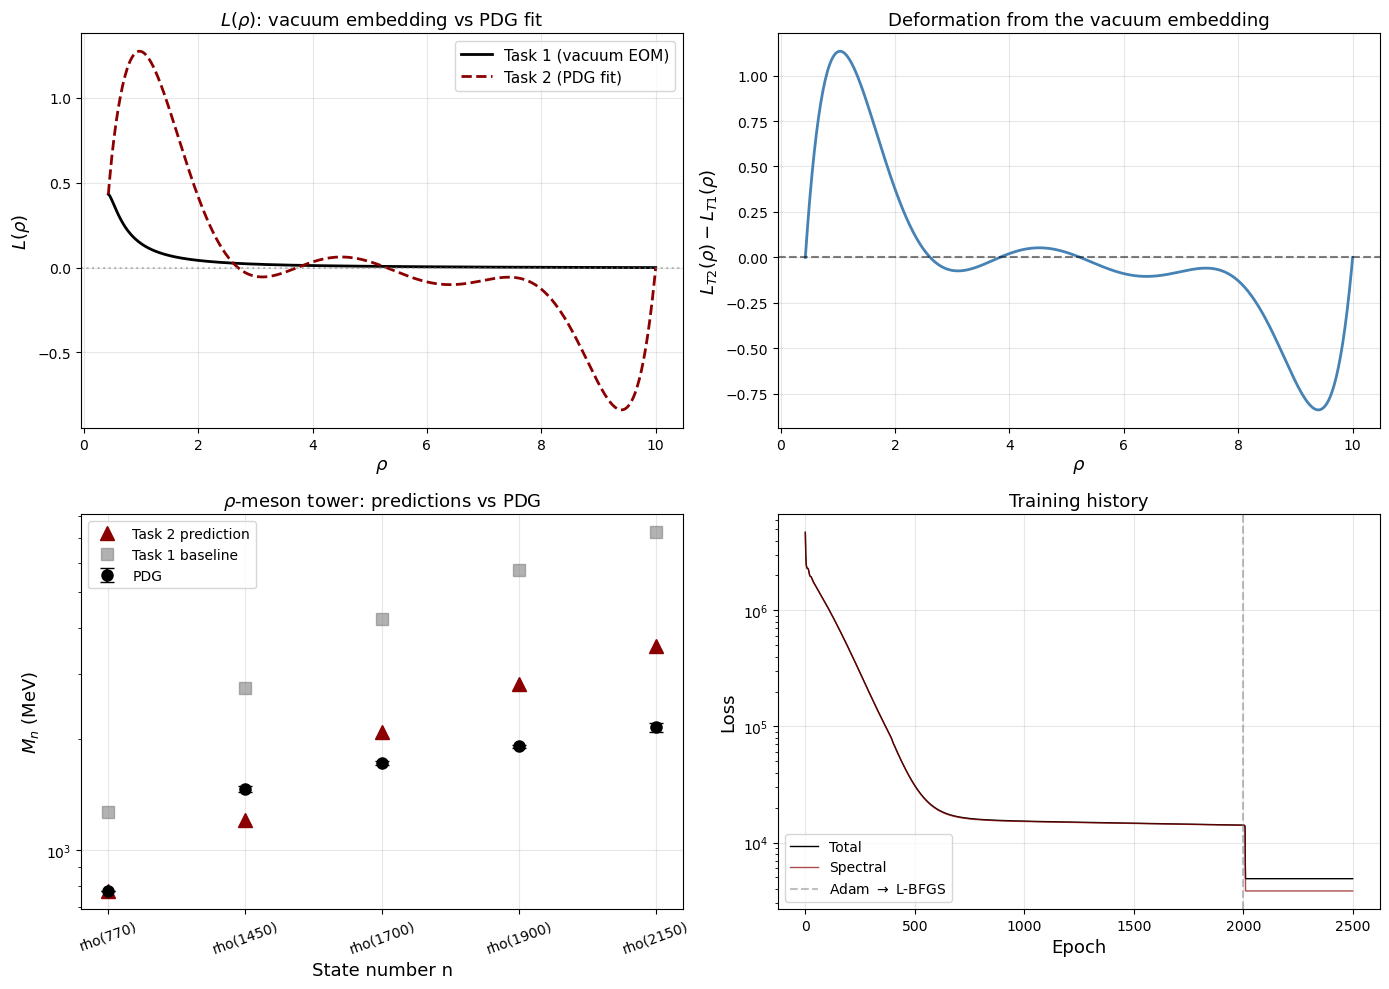


L(rho) deformation characteristics:
  Max L: 1.2737
  Min L: -0.8381
  All positive: False
  Max |deviation from Task 1|: 1.1337


In [20]:
# Final results and plots

# Final predictions
with torch.no_grad():
    L_final = L_parametric(coeffs_param)
    M_bare_final = vector_meson_eigvals_torch(L_final)
    f_pi_bare_final = f_pi_torch(L_final)
    M_phys_final = Lambda_param * M_bare_final
    f_pi_phys_final = Lambda_param * f_pi_bare_final

print("=" * 80)
print("Task 2 final results — parametric Chebyshev ansatz")
print("=" * 80)
print("\nFitted Chebyshev coefficients:")
for k in range(K_modes):
    print(f"  a_{k} = {coeffs_param[k].item():+.6f}")

print(f"\nFitted scale: Lambda = {Lambda_param.item():.4f} MeV/bare")

print(f"\n{'State':<12s}  {'Predicted':>12s}  {'PDG':>10s}  {'sigma':>8s}  "
      f"{'Diff':>10s}  {'Pull':>8s}")
print("-" * 75)

chi_squared_final = 0.0
for i in range(5):
    M_p = M_phys_final[i].item()
    M_e = PDG_rho_masses[i]
    sigma = PDG_rho_sigmas[i]
    diff = M_p - M_e
    pull = diff / sigma
    chi_squared_final += pull**2
    print(f"{state_names[i]:<12s}  {M_p:>12.2f}  {M_e:>10.2f}  {sigma:>8.2f}  "
          f"{diff:>+10.2f}  {pull:>+8.2f}")

fpi_p = f_pi_phys_final.item()
fpi_diff = fpi_p - f_pi_PDG
fpi_pull = fpi_diff / sigma_fpi_torch.item()
chi_squared_final += fpi_pull**2
print(f"{'f_pi':<12s}  {fpi_p:>12.2f}  {f_pi_PDG:>10.2f}  "
      f"{sigma_fpi_torch.item():>8.2f}  {fpi_diff:>+10.2f}  {fpi_pull:>+8.2f}")

print("-" * 75)
print(f"\nFinal chi^2 = {chi_squared_final:.2f}")
print(f"Reduced chi^2 = {chi_squared_final / 6:.2f}")
print(f"Improvement from Task 1 baseline: {chi_squared_baseline / chi_squared_final:.1e}x")

# Plots
rho_plot = torch.linspace(rho_IR, rho_max, 500, dtype=torch.float64)
with torch.no_grad():
    L_task1_plot = model(rho_plot.unsqueeze(1)).squeeze().numpy()
    L_task2_plot = L_parametric(coeffs_param, rho_values=rho_plot).numpy()

rho_plot_np = rho_plot.numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: L(rho) comparison — Task 1 vacuum vs Task 2 fitted
axes[0, 0].plot(rho_plot_np, L_task1_plot, 'k-', linewidth=2,
                label='Task 1 (vacuum EOM)')
axes[0, 0].plot(rho_plot_np, L_task2_plot, color='darkred', linestyle='--', linewidth=2,
                label='Task 2 (PDG fit)')
axes[0, 0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0, 0].set_xlabel(r'$\rho$', fontsize=13)
axes[0, 0].set_ylabel(r'$L(\rho)$', fontsize=13)
axes[0, 0].set_title(r'$L(\rho)$: vacuum embedding vs PDG fit', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: deformation profile — how far Task 2 wandered from Task 1
axes[0, 1].plot(rho_plot_np, L_task2_plot - L_task1_plot,
                color='steelblue', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel(r'$\rho$', fontsize=13)
axes[0, 1].set_ylabel(r'$L_{T2}(\rho) - L_{T1}(\rho)$', fontsize=13)
axes[0, 1].set_title('Deformation from the vacuum embedding', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Predicted vs PDG
M_pred_plot = M_phys_final.detach().numpy()
axes[1, 0].errorbar(range(1, 6), PDG_rho_masses, yerr=PDG_rho_sigmas,
                    fmt='ko', markersize=8, capsize=5, label='PDG')
axes[1, 0].plot(range(1, 6), M_pred_plot,
                color='darkred', marker='^', markersize=10, linestyle='',
                label='Task 2 prediction')
axes[1, 0].plot(range(1, 6), M_phys_baseline,
                color='gray', marker='s', markersize=8, linestyle='', alpha=0.6,
                label='Task 1 baseline')
axes[1, 0].set_xlabel('State number n', fontsize=13)
axes[1, 0].set_ylabel(r'$M_n$ (MeV)', fontsize=13)
axes[1, 0].set_title(r'$\rho$-meson tower: predictions vs PDG', fontsize=13)
axes[1, 0].set_xticks(range(1, 6))
axes[1, 0].set_xticklabels(state_names, rotation=20)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Training history
axes[1, 1].semilogy(history_t2['total'], 'k-', linewidth=1, label='Total')
axes[1, 1].semilogy(history_t2['spec'], color='darkred', linewidth=1, alpha=0.7,
                    label='Spectral')
axes[1, 1].axvline(x=n_adam_t2, color='gray', linestyle='--', alpha=0.5,
                   label=r'Adam $\to$ L-BFGS')
axes[1, 1].set_xlabel('Epoch', fontsize=13)
axes[1, 1].set_ylabel('Loss', fontsize=13)
axes[1, 1].set_title('Training history', fontsize=13)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nL(rho) deformation characteristics:")
print(f"  Max L: {np.max(L_task2_plot):.4f}")
print(f"  Min L: {np.min(L_task2_plot):.4f}")
print(f"  All positive: {bool(np.all(L_task2_plot >= 0))}")
print(f"  Max |deviation from Task 1|: {np.max(np.abs(L_task2_plot - L_task1_plot)):.4f}")

---
## Summary and discussion

### What we built

A fully-differentiable Python pipeline for the Dynamic AdS/YM model:

1. **Task 1 — Forward PINN for the vacuum embedding** $L(\rho)$. The 5-layer tanh network with hard-enforced Dirichlet boundary conditions converges to the scipy shooting ground truth to a max absolute error of $\sim 10^{-3}$.
2. **Chebyshev spectral collocation** infrastructure (51 points, exponential convergence).
3. **Differentiable PyTorch vector meson eigensolve** matching the Mathematica reference to better than 0.2%.
4. **Differentiable PyTorch $f_\pi$ computation** via linear solve plus trapezoidal integration, matching Mathematica to $\sim 10^{-5}$.
5. **Task 2 — Inverse fit** with a 7-parameter Chebyshev expansion against the PDG $\rho$-meson tower plus $f_\pi$.

### What we found

- **Task 1 baseline** (vacuum embedding with $f_\pi$ anchoring): $\chi^2 \approx 5 \times 10^6$. Every meson mass is over-predicted by 66% to 240%.
- **Task 2 fit** (parametric Chebyshev): $\chi^2 \approx 3.8 \times 10^3$. A factor of $\sim 1200$ improvement, but the reduced $\chi^2 \approx 640$ is far from a good fit.

The lowest two states and $f_\pi$ are fit at the few-MeV level, but the residuals at $\rho(1700)$, $\rho(1900)$, and $\rho(2150)$ remain at the level of hundreds to thousands of MeV.

### Physical interpretation

The Dynamic AdS/YM model in the chiral limit produces a near-linear-in-$n$ vector meson spectrum, with bare-unit masses $\tilde{M}_n \propto n$ to good approximation. Experimentally, the $\rho$-meson tower follows a Regge-like pattern $M_n^2 \propto n$ instead. This is a structural mismatch in the spectral *shape*, not just the overall scale. The parametric fit confirms that no smooth, physical deformation of $L(\rho)$ within the standard chiral limit framework can resolve this mismatch.

This finding is consistent with the published analysis in Erdmenger, Evans, Porod, and Rigatos (arXiv:2010.10279), where the same limitation is noted in the context of the AdS/CFT correspondence's inability to capture stringy excited-state behaviour at finite $N_c$.

### Future directions

The natural extension is to include **higher-dimensional operators (HDOs)** via Witten's double-trace prescription (arXiv:hep-th/0112258). Concretely, the boundary condition $L(\rho_{\text{max}}) = 0$ is relaxed so that the source/operator relationship at the UV is modified by a coupling $G$ to a higher-dimensional operator. This single additional parameter can in principle improve the fit to the lowest excited state, as discussed in arXiv:2010.10279.

A different direction is to apply the same pipeline to a richer model with additional bulk fields (axial mesons, scalar mesons), where the inverse problem has more data to constrain and the spectrum can include modes with different node counts.